# Confusion Matrix & Classification Metrics

## Overview
A **Confusion Matrix** is a table that summarizes the performance of a classification model
by comparing predicted vs actual class labels.

### Binary Confusion Matrix:
```
                  Predicted
                Positive  Negative
Actual Positive    TP        FN
Actual Negative    FP        TN
```

### Core Metrics:
| Metric | Formula | When to use |
|--------|---------|-------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Balanced classes |
| Precision | TP/(TP+FP) | Cost of false positives is high |
| Recall | TP/(TP+FN) | Cost of false negatives is high |
| F1 Score | 2*(P*R)/(P+R) | Imbalanced classes |
| ROC-AUC | Area under ROC curve | Ranking ability |
| MCC | Balanced metric for all 4 cells | Most robust single metric |

---
### Topics Covered
1. Confusion matrix anatomy
2. All binary classification metrics
3. Threshold tuning — Precision vs Recall tradeoff
4. ROC curve and AUC
5. Precision-Recall curve
6. Multiclass confusion matrix
7. Imbalanced classes — what goes wrong
8. Matthews Correlation Coefficient (MCC)
9. Real-world offline-safe examples
10. Metric selection guide


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, matthews_corrcoef,
    balanced_accuracy_score
)

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'tertiary':  '#9B59B6',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Confusion Matrix Anatomy

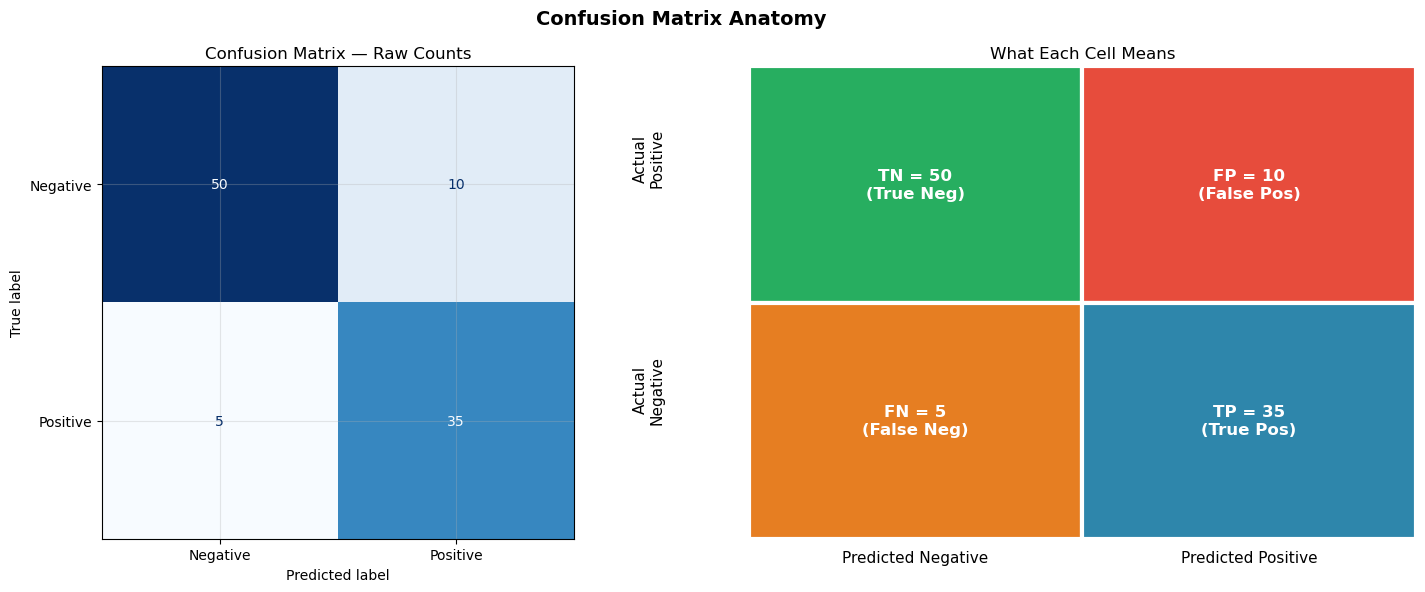

TP=35  FP=10  TN=50  FN=5  Total=100

TP (True  Positive) : Model said YES, actual YES  -> correct
TN (True  Negative) : Model said NO,  actual NO   -> correct
FP (False Positive) : Model said YES, actual NO   -> Type I error
FN (False Negative) : Model said NO,  actual YES  -> Type II error


In [2]:
# Manually define a confusion matrix to explain each cell
cm_example = np.array([[50, 10],
                        [5,  35]])
# rows = actual, cols = predicted
# [0,0]=TN  [0,1]=FP
# [1,0]=FN  [1,1]=TP

TN, FP = cm_example[0]
FN, TP = cm_example[1]
total  = TN + FP + FN + TP

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raw confusion matrix
disp = ConfusionMatrixDisplay(cm_example,
                               display_labels=['Negative','Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=12)

# Annotated explanation
cell_labels = [
    [f'TN = {TN}\n(True Neg)', f'FP = {FP}\n(False Pos)'],
    [f'FN = {FN}\n(False Neg)', f'TP = {TP}\n(True Pos)']
]
cell_colors = [
    ['#27AE60', '#E74C3C'],
    ['#E67E22', '#2E86AB']
]
ax2 = axes[1]
ax2.set_xlim(0, 2); ax2.set_ylim(0, 2)
ax2.axis('off')
ax2.set_title('What Each Cell Means', fontsize=12)
for i in range(2):
    for j in range(2):
        rect = plt.Rectangle((j, 1-i), 1, 1,
                              facecolor=cell_colors[i][j],
                              edgecolor='white', linewidth=3)
        ax2.add_patch(rect)
        ax2.text(j+0.5, 1-i+0.5, cell_labels[i][j],
                 ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white')
ax2.text(0.5, -0.1, 'Predicted Negative', ha='center', fontsize=11)
ax2.text(1.5, -0.1, 'Predicted Positive', ha='center', fontsize=11)
ax2.text(-0.3, 1.5, 'Actual\nPositive', ha='center', fontsize=11, rotation=90)
ax2.text(-0.3, 0.5, 'Actual\nNegative', ha='center', fontsize=11, rotation=90)

plt.suptitle('Confusion Matrix Anatomy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'TP={TP}  FP={FP}  TN={TN}  FN={FN}  Total={total}')
print()
print('TP (True  Positive) : Model said YES, actual YES  -> correct')
print('TN (True  Negative) : Model said NO,  actual NO   -> correct')
print('FP (False Positive) : Model said YES, actual NO   -> Type I error')
print('FN (False Negative) : Model said NO,  actual YES  -> Type II error')

## 3. All Binary Classification Metrics

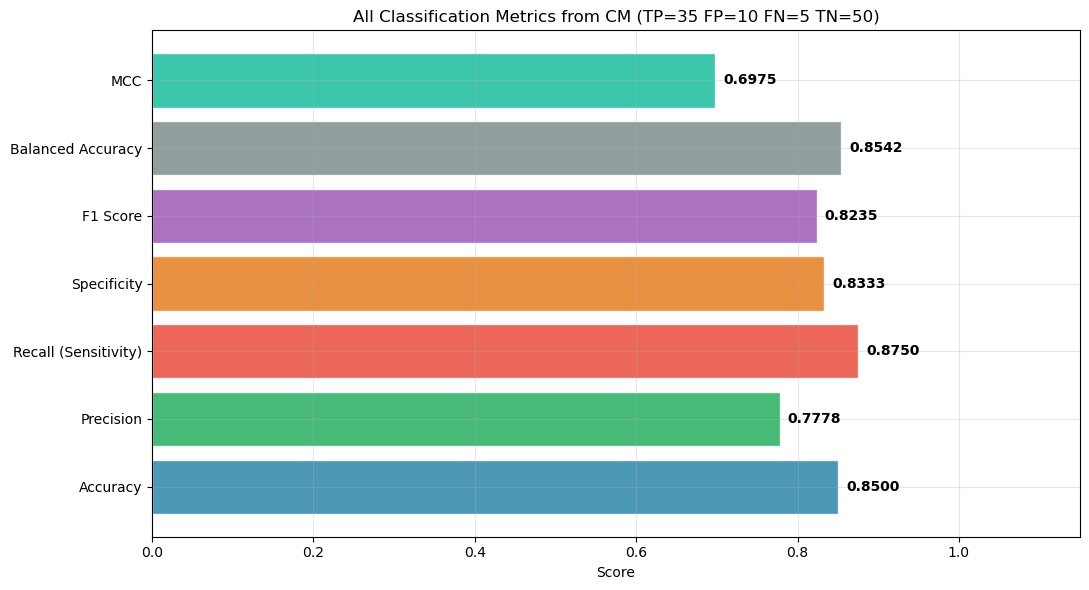

Metric formulas:
  Accuracy        = (TP+TN)/Total          = 0.8500
  Precision       = TP/(TP+FP)             = 0.7778
  Recall          = TP/(TP+FN)             = 0.8750
  Specificity     = TN/(TN+FP)             = 0.8333
  F1 Score        = 2*P*R/(P+R)            = 0.8235
  Balanced Acc    = (Recall+Specificity)/2 = 0.8542
  MCC             = (TP*TN-FP*FN)/sqrt(..) = 0.6975


In [3]:
TN, FP, FN, TP = 50, 10, 5, 35

accuracy   = (TP + TN) / (TP + TN + FP + FN)
precision  = TP / (TP + FP)
recall     = TP / (TP + FN)
specificity= TN / (TN + FP)
f1         = 2 * precision * recall / (precision + recall)
mcc_num    = (TP*TN - FP*FN)
mcc_den    = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
mcc        = mcc_num / mcc_den
balanced_acc = (recall + specificity) / 2

metrics = {
    'Accuracy':          accuracy,
    'Precision':         precision,
    'Recall (Sensitivity)': recall,
    'Specificity':       specificity,
    'F1 Score':          f1,
    'Balanced Accuracy': balanced_acc,
    'MCC':               mcc,
}

fig, ax = plt.subplots(figsize=(11, 6))
colors_bar = [COLORS['primary'], COLORS['success'], COLORS['danger'],
              COLORS['secondary'], COLORS['tertiary'],
              COLORS['neutral'], '#1ABC9C']
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=colors_bar, edgecolor='white', alpha=0.85)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score')
ax.set_title('All Classification Metrics from CM (TP=35 FP=10 FN=5 TN=50)')
for bar, val in zip(bars, metrics.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Metric formulas:')
print(f'  Accuracy        = (TP+TN)/Total          = {accuracy:.4f}')
print(f'  Precision       = TP/(TP+FP)             = {precision:.4f}')
print(f'  Recall          = TP/(TP+FN)             = {recall:.4f}')
print(f'  Specificity     = TN/(TN+FP)             = {specificity:.4f}')
print(f'  F1 Score        = 2*P*R/(P+R)            = {f1:.4f}')
print(f'  Balanced Acc    = (Recall+Specificity)/2 = {balanced_acc:.4f}')
print(f'  MCC             = (TP*TN-FP*FN)/sqrt(..) = {mcc:.4f}')

## 4. Fit a Real Model & Evaluate

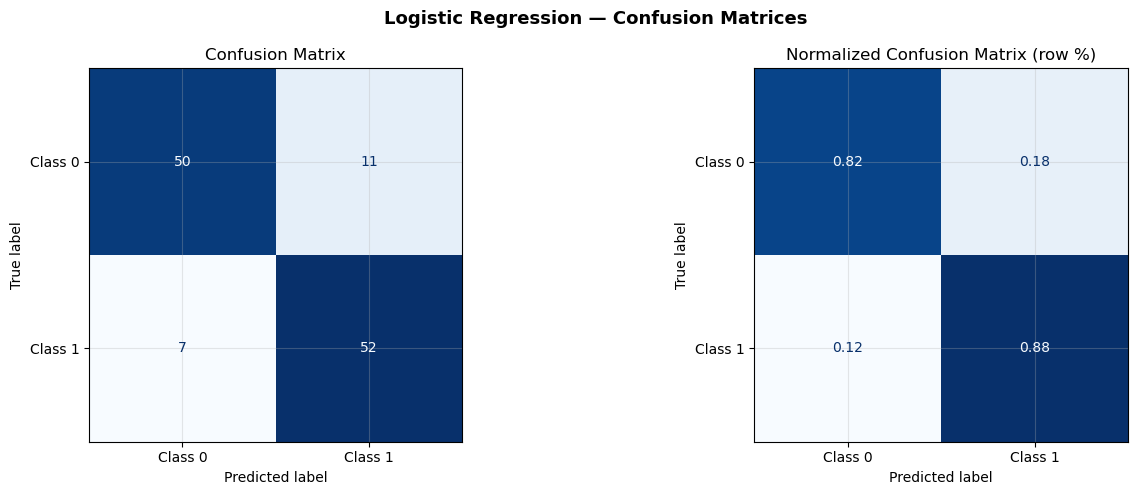

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.82      0.85        61
     Class 1       0.83      0.88      0.85        59

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85      0.85       120

MCC               : 0.7018
Balanced Accuracy : 0.8505


In [4]:
np.random.seed(42)
X, y = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=500)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2),
                        display_labels=['Class 0','Class 1']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalized Confusion Matrix (row %)')

plt.suptitle('Logistic Regression — Confusion Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Class 0','Class 1']))
print(f'MCC               : {matthews_corrcoef(y_test, y_pred):.4f}')
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}')

## 5. Threshold Tuning — Precision vs Recall Tradeoff

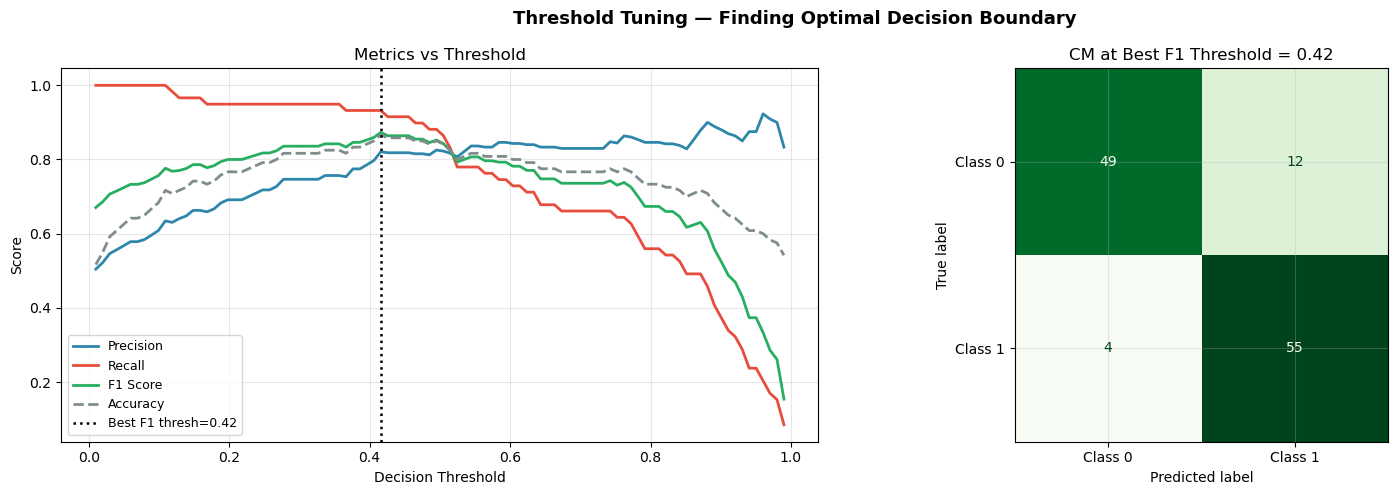

Default threshold (0.5) -> F1=0.8525
Best F1 threshold (0.42) -> F1=0.8730

Lower threshold -> higher Recall, lower Precision (catch more positives)
Higher threshold -> higher Precision, lower Recall (be more selective)


In [5]:
thresholds  = np.linspace(0.01, 0.99, 100)
precisions  = []
recalls     = []
f1s         = []
accuracies  = []

for t in thresholds:
    y_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(   recall_score(   y_test, y_t, zero_division=0))
    f1s.append(       f1_score(       y_test, y_t, zero_division=0))
    accuracies.append(accuracy_score( y_test, y_t))

best_f1_idx  = np.argmax(f1s)
best_thresh  = thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, precisions,  color=COLORS['primary'],
             linewidth=2, label='Precision')
axes[0].plot(thresholds, recalls,     color=COLORS['danger'],
             linewidth=2, label='Recall')
axes[0].plot(thresholds, f1s,         color=COLORS['success'],
             linewidth=2, label='F1 Score')
axes[0].plot(thresholds, accuracies,  color=COLORS['neutral'],
             linewidth=2, linestyle='--', label='Accuracy')
axes[0].axvline(best_thresh, color='black', linestyle=':',
                linewidth=1.8, label=f'Best F1 thresh={best_thresh:.2f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend(fontsize=9)

# Show CM at best threshold
y_best = (y_prob >= best_thresh).astype(int)
cm_best = confusion_matrix(y_test, y_best)
ConfusionMatrixDisplay(cm_best,
                        display_labels=['Class 0','Class 1']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'CM at Best F1 Threshold = {best_thresh:.2f}')

plt.suptitle('Threshold Tuning — Finding Optimal Decision Boundary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Default threshold (0.5) -> F1={f1_score(y_test, y_pred):.4f}')
print(f'Best F1 threshold ({best_thresh:.2f}) -> F1={f1s[best_f1_idx]:.4f}')
print()
print('Lower threshold -> higher Recall, lower Precision (catch more positives)')
print('Higher threshold -> higher Precision, lower Recall (be more selective)')

## 6. ROC Curve & AUC

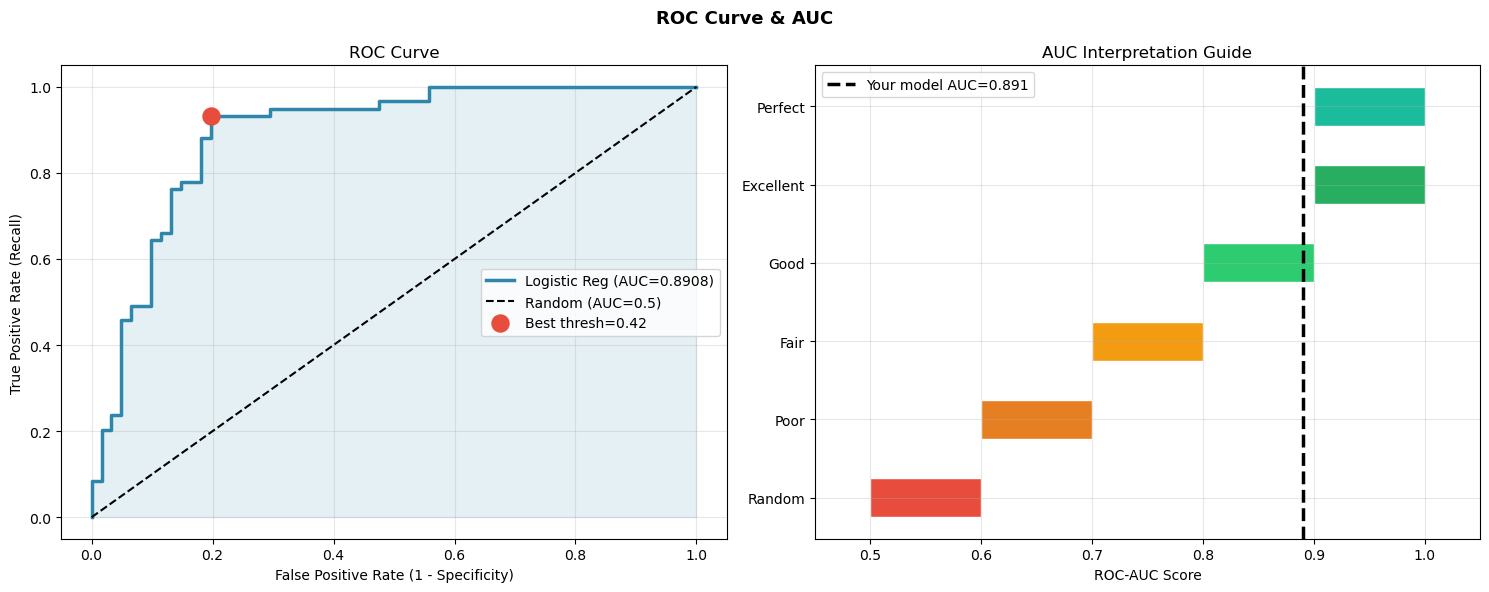

ROC-AUC     : 0.8908
Best thresh : 0.4181  (closest to top-left corner)

AUC = probability that model ranks a random positive
      higher than a random negative.


In [6]:
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

# Find threshold closest to top-left corner
dists     = np.sqrt(fpr**2 + (1-tpr)**2)
best_idx  = np.argmin(dists)
best_fpr  = fpr[best_idx]
best_tpr  = tpr[best_idx]
best_roc_thresh = roc_thresh[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color=COLORS['primary'], linewidth=2.5,
             label=f'Logistic Reg (AUC={auc_val:.4f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.12, color=COLORS['primary'])
axes[0].scatter(best_fpr, best_tpr, color=COLORS['danger'],
                s=150, zorder=5,
                label=f'Best thresh={best_roc_thresh:.2f}')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()

# AUC interpretation guide
auc_levels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
auc_labels = ['Random','Poor','Fair','Good','Excellent','Perfect']
auc_colors = ['#E74C3C','#E67E22','#F39C12','#2ECC71','#27AE60','#1ABC9C']
bars2 = axes[1].barh(auc_labels,
                     [0.1]*6,
                     left=auc_levels[:-1] + [0.9],
                     color=auc_colors, edgecolor='white', height=0.5)
axes[1].set_xlim(0.45, 1.05)
axes[1].axvline(auc_val, color='black', linewidth=2.5,
                linestyle='--', label=f'Your model AUC={auc_val:.3f}')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_title('AUC Interpretation Guide')
axes[1].legend()

plt.suptitle('ROC Curve & AUC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'ROC-AUC     : {auc_val:.4f}')
print(f'Best thresh : {best_roc_thresh:.4f}  (closest to top-left corner)')
print()
print('AUC = probability that model ranks a random positive')
print('      higher than a random negative.')

## 7. Precision-Recall Curve

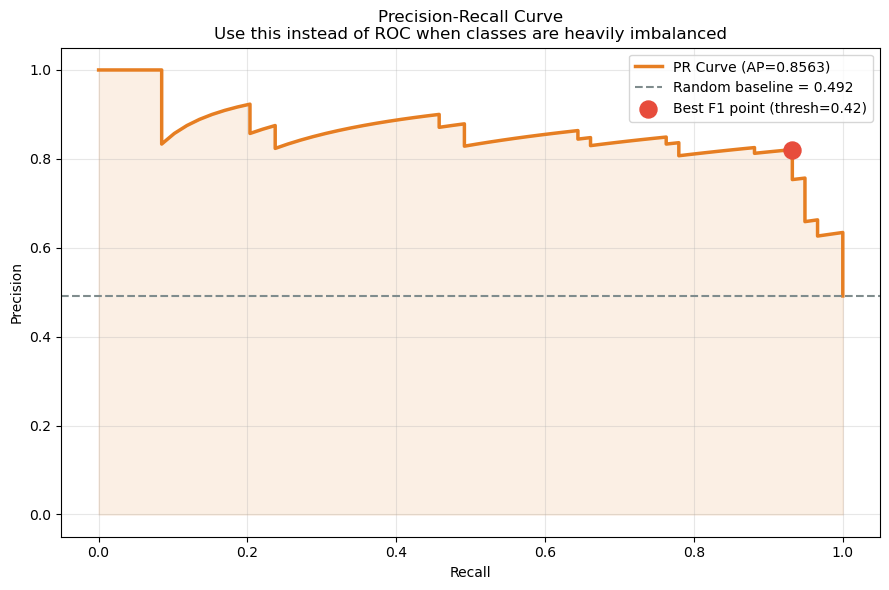

Average Precision (AP) : 0.8563
Baseline (class ratio) : 0.4917

PR Curve is better than ROC when:
  - Classes are heavily imbalanced (e.g. fraud, disease detection)
  - You care more about the positive class performance
  - TN count is very large and dominates ROC


In [7]:
prec_curve, rec_curve, pr_thresh = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

# Best F1 on PR curve
f1_curve  = 2*prec_curve*rec_curve / (prec_curve+rec_curve+1e-9)
best_pr   = np.argmax(f1_curve)

plt.figure(figsize=(9, 6))
plt.plot(rec_curve, prec_curve, color=COLORS['secondary'],
         linewidth=2.5, label=f'PR Curve (AP={avg_prec:.4f})')
plt.axhline(baseline, color=COLORS['neutral'], linestyle='--',
            linewidth=1.5, label=f'Random baseline = {baseline:.3f}')
plt.scatter(rec_curve[best_pr], prec_curve[best_pr],
            color=COLORS['danger'], s=150, zorder=5,
            label=f'Best F1 point (thresh={pr_thresh[best_pr]:.2f})')
plt.fill_between(rec_curve, prec_curve, alpha=0.12, color=COLORS['secondary'])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve\n'
          'Use this instead of ROC when classes are heavily imbalanced')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average Precision (AP) : {avg_prec:.4f}')
print(f'Baseline (class ratio) : {baseline:.4f}')
print()
print('PR Curve is better than ROC when:')
print('  - Classes are heavily imbalanced (e.g. fraud, disease detection)')
print('  - You care more about the positive class performance')
print('  - TN count is very large and dominates ROC')

## 8. Multiclass Confusion Matrix

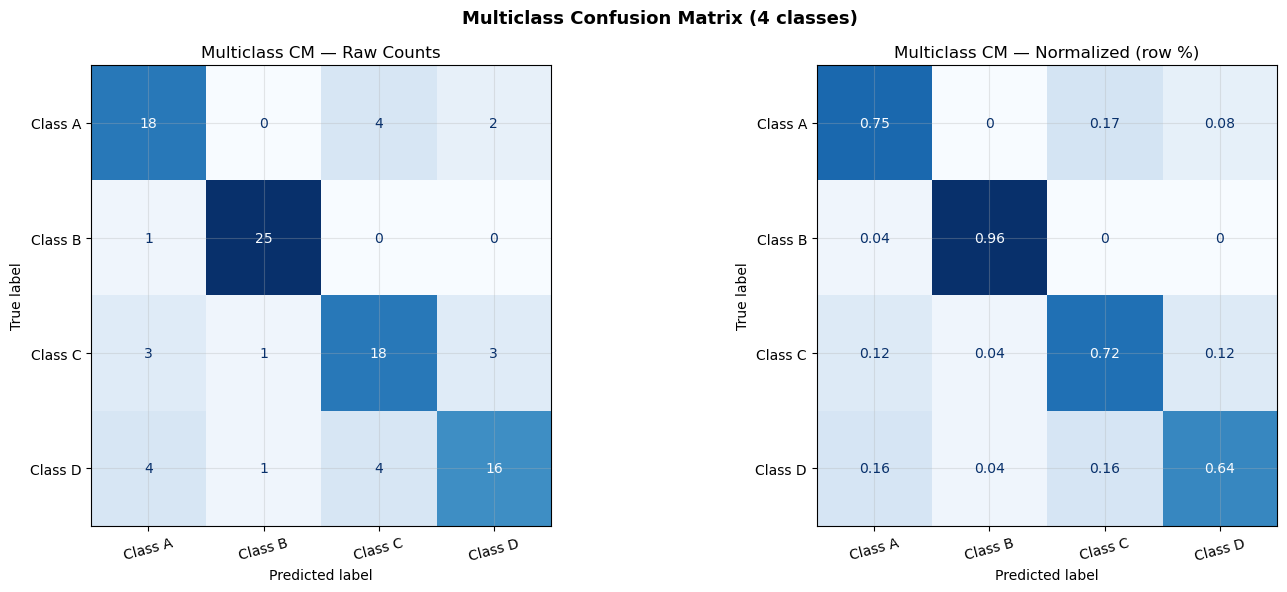

Classification Report (multiclass):
              precision    recall  f1-score   support

     Class A       0.69      0.75      0.72        24
     Class B       0.93      0.96      0.94        26
     Class C       0.69      0.72      0.71        25
     Class D       0.76      0.64      0.70        25

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100

Diagonal = correctly classified. Off-diagonal = misclassified.
Normalized CM shows the error RATE per class (row-wise).


In [8]:
np.random.seed(42)
X_mc, y_mc = make_classification(
    n_samples=500, n_features=10, n_informative=7,
    n_redundant=2, n_classes=4, n_clusters_per_class=1,
    random_state=42
)
X_mc_tr, X_mc_te, y_mc_tr, y_mc_te = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)
sc_mc      = StandardScaler()
X_mc_tr_sc = sc_mc.fit_transform(X_mc_tr)
X_mc_te_sc = sc_mc.transform(X_mc_te)

mc_model   = LogisticRegression(max_iter=500, random_state=42)
mc_model.fit(X_mc_tr_sc, y_mc_tr)
y_mc_pred  = mc_model.predict(X_mc_te_sc)

cm_mc      = confusion_matrix(y_mc_te, y_mc_pred)
cm_mc_norm = cm_mc.astype(float) / cm_mc.sum(axis=1, keepdims=True)

class_names = ['Class A','Class B','Class C','Class D']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(cm_mc, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Multiclass CM — Raw Counts')
axes[0].tick_params(axis='x', rotation=15)

ConfusionMatrixDisplay(cm_mc_norm.round(2),
                        display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Multiclass CM — Normalized (row %)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Multiclass Confusion Matrix (4 classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report (multiclass):')
print(classification_report(y_mc_te, y_mc_pred, target_names=class_names))
print('Diagonal = correctly classified. Off-diagonal = misclassified.')
print('Normalized CM shows the error RATE per class (row-wise).')

## 9. Imbalanced Classes — What Goes Wrong

Class balance : [946  54]  (0=Normal, 1=Fraud)



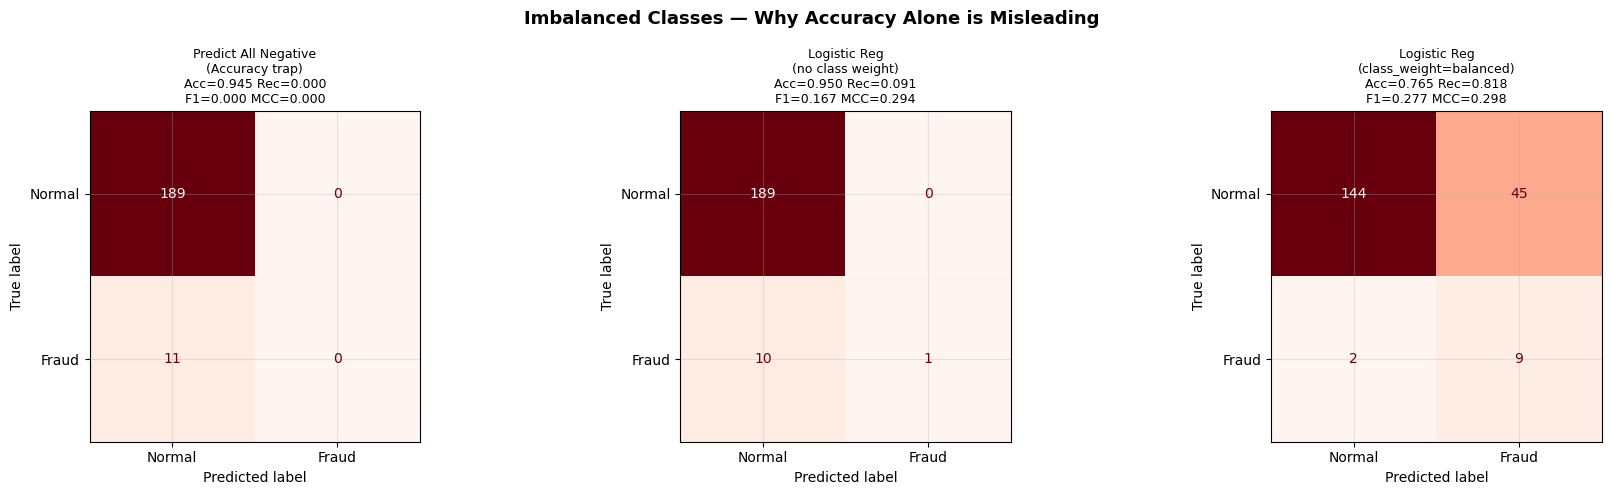

LESSON: 95% accuracy by predicting all-negative is USELESS.
Use Recall, F1, MCC or Balanced Accuracy for imbalanced data.


In [9]:
np.random.seed(42)
# 95% negative, 5% positive (fraud-style imbalance)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    n_redundant=2, weights=[0.95, 0.05],
    random_state=42
)
X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)
sc_imb = StandardScaler()
X_imb_tr_sc = sc_imb.fit_transform(X_imb_tr)
X_imb_te_sc = sc_imb.transform(X_imb_te)

print(f'Class balance : {np.bincount(y_imb)}  (0=Normal, 1=Fraud)')
print()

# Dummy: predict all negative
y_all_neg = np.zeros(len(y_imb_te), dtype=int)

# Logistic Regression without class weight
lr_imb = LogisticRegression(max_iter=500, random_state=42)
lr_imb.fit(X_imb_tr_sc, y_imb_tr)
y_lr_pred = lr_imb.predict(X_imb_te_sc)

# Logistic Regression with balanced class weight
lr_bal = LogisticRegression(max_iter=500, class_weight='balanced',
                             random_state=42)
lr_bal.fit(X_imb_tr_sc, y_imb_tr)
y_bal_pred = lr_bal.predict(X_imb_te_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_imb = [
    ('Predict All Negative\n(Accuracy trap)', y_all_neg),
    ('Logistic Reg\n(no class weight)',       y_lr_pred),
    ('Logistic Reg\n(class_weight=balanced)', y_bal_pred),
]
for ax, (title, y_pred_imb) in zip(axes, models_imb):
    cm_imb = confusion_matrix(y_imb_te, y_pred_imb)
    ConfusionMatrixDisplay(cm_imb,
                            display_labels=['Normal','Fraud']).plot(
        ax=ax, colorbar=False, cmap='Reds')
    acc  = accuracy_score(y_imb_te, y_pred_imb)
    rec  = recall_score(  y_imb_te, y_pred_imb, zero_division=0)
    f1v  = f1_score(      y_imb_te, y_pred_imb, zero_division=0)
    mcc_v= matthews_corrcoef(y_imb_te, y_pred_imb)
    ax.set_title(f'{title}\nAcc={acc:.3f} Rec={rec:.3f}\nF1={f1v:.3f} MCC={mcc_v:.3f}',
                 fontsize=9)

plt.suptitle('Imbalanced Classes — Why Accuracy Alone is Misleading',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('LESSON: 95% accuracy by predicting all-negative is USELESS.')
print('Use Recall, F1, MCC or Balanced Accuracy for imbalanced data.')

## 10. Matthews Correlation Coefficient (MCC)

MCC Formula:
  MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))

Metric comparison across scenarios:
        Scenario  TP  FN  FP  TN  Accuracy  Precision  Recall    F1   MCC
   Perfect model  90   0   0  10     1.000      1.000   1.000 1.000 1.000
      Good model  80  10   5  55     0.900      0.941   0.889 0.914 0.796
Biased (all pos)  50   0  50   0     0.500      0.500   1.000 0.667 0.000
Biased (all neg)   0  50   0  50     0.500      0.000   0.000 0.000 0.000
    Random model  45  30  20  55     0.667      0.692   0.600 0.643 0.336


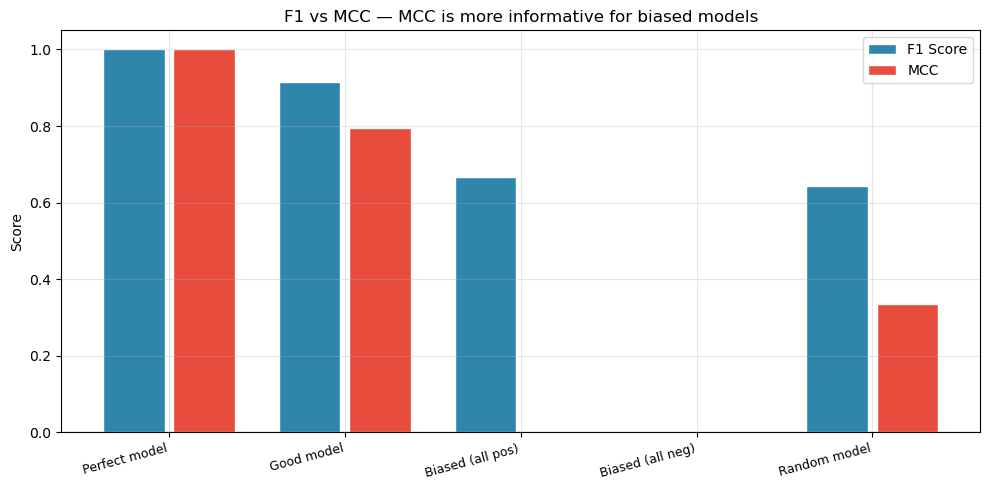


MCC = 0 for BOTH "all positive" and "all negative" predictions -> honest
F1  = 0 only for "all negative" -> can be misleadingly high for "all positive"


In [10]:
# MCC works well for imbalanced and balanced datasets
# Range: -1 (perfect wrong) to +1 (perfect correct), 0 = random

print('MCC Formula:')
print('  MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))')
print()

# Compare metrics across different scenarios
scenarios = [
    ('Perfect model',       90,  0,  0, 10),
    ('Good model',          80, 10,  5, 55),
    ('Biased (all pos)',    50,  0, 50,  0),
    ('Biased (all neg)',     0, 50,  0, 50),
    ('Random model',        45, 30, 20, 55),
]

rows = []
for name, TP, FN, FP, TN in scenarios:
    total = TP + FN + FP + TN
    acc   = (TP+TN)/total
    prec  = TP/(TP+FP) if (TP+FP)>0 else 0
    rec   = TP/(TP+FN) if (TP+FN)>0 else 0
    f1v   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    denom = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc_v = (TP*TN-FP*FN)/denom if denom>0 else 0
    rows.append({
        'Scenario': name,
        'TP':TP,'FN':FN,'FP':FP,'TN':TN,
        'Accuracy': round(acc,3),
        'Precision':round(prec,3),
        'Recall':   round(rec,3),
        'F1':       round(f1v,3),
        'MCC':      round(mcc_v,3)
    })

df_mcc = pd.DataFrame(rows)
print('Metric comparison across scenarios:')
print(df_mcc.to_string(index=False))

# Plot MCC vs F1
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(df_mcc))
ax.bar(x_pos - 0.2, df_mcc['F1'],  0.35, label='F1 Score',
       color=COLORS['primary'], edgecolor='white')
ax.bar(x_pos + 0.2, df_mcc['MCC'], 0.35, label='MCC',
       color=COLORS['danger'],  edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_mcc['Scenario'], rotation=15, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Score')
ax.set_title('F1 vs MCC — MCC is more informative for biased models')
ax.legend()
plt.tight_layout()
plt.show()

print()
print('MCC = 0 for BOTH "all positive" and "all negative" predictions -> honest')
print('F1  = 0 only for "all negative" -> can be misleadingly high for "all positive"')

## 11. Model Comparison — Multiple Models

=== Model Comparison ===
              Model  Accuracy  Precision  Recall     F1  ROC-AUC    MCC
Logistic Regression    0.7750     0.7705  0.7833 0.7769   0.8461 0.5501
      Random Forest    0.8667     0.8333  0.9167 0.8730   0.9203 0.7370
          SVM (RBF)    0.8667     0.8235  0.9333 0.8750   0.9139 0.7399


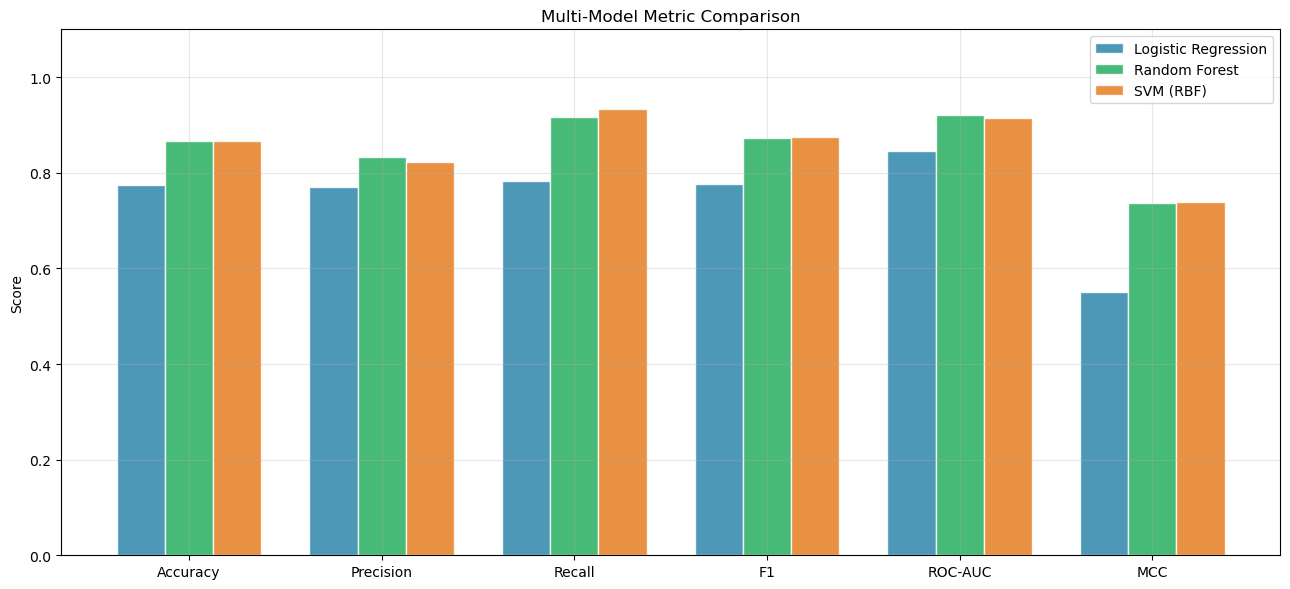

In [11]:
np.random.seed(42)
X_cmp, y_cmp = make_classification(
    n_samples=600, n_features=15, n_informative=8,
    n_redundant=4, random_state=42
)
X_cmp_tr, X_cmp_te, y_cmp_tr, y_cmp_te = train_test_split(
    X_cmp, y_cmp, test_size=0.2, random_state=42, stratify=y_cmp
)
sc_cmp = StandardScaler()
X_cmp_tr_sc = sc_cmp.fit_transform(X_cmp_tr)
X_cmp_te_sc = sc_cmp.transform(X_cmp_te)

models_cmp = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
}

rows_cmp = []
for name, clf in models_cmp.items():
    clf.fit(X_cmp_tr_sc, y_cmp_tr)
    yp   = clf.predict(X_cmp_te_sc)
    prob = clf.predict_proba(X_cmp_te_sc)[:,1]
    rows_cmp.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_cmp_te, yp),4),
        'Precision': round(precision_score(y_cmp_te, yp),4),
        'Recall':    round(recall_score(y_cmp_te, yp),4),
        'F1':        round(f1_score(y_cmp_te, yp),4),
        'ROC-AUC':   round(roc_auc_score(y_cmp_te, prob),4),
        'MCC':       round(matthews_corrcoef(y_cmp_te, yp),4),
    })

df_cmp = pd.DataFrame(rows_cmp)
print('=== Model Comparison ===')
print(df_cmp.to_string(index=False))

metric_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC','MCC']
x_pos = np.arange(len(metric_cols))
width = 0.25
colors_cmp = [COLORS['primary'], COLORS['success'], COLORS['secondary']]

plt.figure(figsize=(13, 6))
for i, (_, row) in enumerate(df_cmp.iterrows()):
    plt.bar(x_pos + i*width,
            [row[m] for m in metric_cols],
            width, label=row['Model'],
            color=colors_cmp[i], edgecolor='white', alpha=0.85)

plt.xticks(x_pos + width, metric_cols, fontsize=10)
plt.ylabel('Score')
plt.title('Multi-Model Metric Comparison')
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 12. Metric Selection Guide

In [12]:
print('=' * 66)
print('         METRIC SELECTION GUIDE')
print('=' * 66)

guide = [
    ('Balanced classes',      'Accuracy, F1, MCC'),
    ('Imbalanced classes',    'F1, MCC, Balanced Accuracy, PR-AUC'),
    ('FP cost is high',       'Precision (e.g. spam filter)'),
    ('FN cost is high',       'Recall (e.g. cancer screening)'),
    ('Ranking ability',       'ROC-AUC (threshold-independent)'),
    ('Severe imbalance',      'PR-AUC / Average Precision'),
    ('Best single metric',    'MCC (considers all 4 CM cells)'),
    ('Multiclass balanced',   'Macro F1, Macro MCC'),
    ('Multiclass imbalanced', 'Weighted F1, Balanced Accuracy'),
    ('Business decisions',    'Custom cost matrix (FP cost vs FN cost)'),
]

for situation, metric in guide:
    print(f'  {situation:<30}  ->  {metric}')

print()
print('Common Mistakes:')
mistakes = [
    'Using Accuracy alone on imbalanced data',
    'Ignoring threshold tuning (default 0.5 is often not optimal)',
    'Using ROC-AUC when classes are very imbalanced (use PR-AUC)',
    'Reporting only one metric — always report F1 + AUC + MCC together',
    'Not looking at the confusion matrix directly',
]
for m in mistakes:
    print(f'  WRONG: {m}')

print('=' * 66)

         METRIC SELECTION GUIDE
  Balanced classes                ->  Accuracy, F1, MCC
  Imbalanced classes              ->  F1, MCC, Balanced Accuracy, PR-AUC
  FP cost is high                 ->  Precision (e.g. spam filter)
  FN cost is high                 ->  Recall (e.g. cancer screening)
  Ranking ability                 ->  ROC-AUC (threshold-independent)
  Severe imbalance                ->  PR-AUC / Average Precision
  Best single metric              ->  MCC (considers all 4 CM cells)
  Multiclass balanced             ->  Macro F1, Macro MCC
  Multiclass imbalanced           ->  Weighted F1, Balanced Accuracy
  Business decisions              ->  Custom cost matrix (FP cost vs FN cost)

Common Mistakes:
  WRONG: Using Accuracy alone on imbalanced data
  WRONG: Ignoring threshold tuning (default 0.5 is often not optimal)
  WRONG: Using ROC-AUC when classes are very imbalanced (use PR-AUC)
  WRONG: Reporting only one metric — always report F1 + AUC + MCC together
  WRONG: Not 

## 13. Final Summary & Key Takeaways

In [13]:
print('=' * 66)
print('     CONFUSION MATRIX & METRICS - KEY TAKEAWAYS')
print('=' * 66)
takeaways = [
    ('CM cells',         'TP, TN, FP, FN — all metrics derive from these 4'),
    ('Accuracy',         'Good for balanced classes; misleading when imbalanced'),
    ('Precision',        'How many predicted positives are actually positive'),
    ('Recall',           'How many actual positives were caught'),
    ('F1 Score',         'Harmonic mean of Precision and Recall'),
    ('ROC-AUC',          'Ranking ability across all thresholds; robust metric'),
    ('PR-AUC',           'Better than ROC when classes are heavily imbalanced'),
    ('MCC',              'Most balanced single metric; robust to class imbalance'),
    ('Threshold tuning', 'Default 0.5 is not always optimal; tune for your goal'),
    ('Normalize CM',     'Row-normalize to compare classes with different sizes'),
    ('class_weight',     'balanced weight helps with imbalanced training data'),
    ('Type I error',     'False Positive = FP = predicted positive, actually negative'),
    ('Type II error',    'False Negative = FN = predicted negative, actually positive'),
]
for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')
print('=' * 66)

     CONFUSION MATRIX & METRICS - KEY TAKEAWAYS
  OK  CM cells            ->  TP, TN, FP, FN — all metrics derive from these 4
  OK  Accuracy            ->  Good for balanced classes; misleading when imbalanced
  OK  Precision           ->  How many predicted positives are actually positive
  OK  Recall              ->  How many actual positives were caught
  OK  F1 Score            ->  Harmonic mean of Precision and Recall
  OK  ROC-AUC             ->  Ranking ability across all thresholds; robust metric
  OK  PR-AUC              ->  Better than ROC when classes are heavily imbalanced
  OK  MCC                 ->  Most balanced single metric; robust to class imbalance
  OK  Threshold tuning    ->  Default 0.5 is not always optimal; tune for your goal
  OK  Normalize CM        ->  Row-normalize to compare classes with different sizes
  OK  class_weight        ->  balanced weight helps with imbalanced training data
  OK  Type I error        ->  False Positive = FP = predicted positive, 

---
## Practice Exercises

1. **Custom cost matrix** — assign cost 10 to FN and 1 to FP, find the threshold that minimizes total cost.
2. **Compare ROC-AUC vs PR-AUC** on a severely imbalanced dataset (1% positive class).
3. **Plot confusion matrices** for all 5 threshold values and observe how TP/FP/FN/TN shift.
4. **Implement MCC from scratch** using only NumPy and verify it matches sklearn.
5. **Multiclass ROC** — use `roc_auc_score(multi_class='ovr', average='macro')` on the 4-class dataset.
6. **Add SMOTE** oversampling to the imbalanced dataset and compare metrics before and after.

---
*Notebook created for the ML Repository — Confusion Matrix & Metrics module.*